# Imports

In [1]:
import os
import cv2
import subprocess
import pandas as pd
from google.cloud import storage
from collections import defaultdict
from IPython.display import Video, display
from google.colab.patches import cv2_imshow

# Set Up

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%capture
!pip install mediapipe
!wget -q -O efficientdet.tflite -q https://storage.googleapis.com/mediapipe-models/object_detector/efficientdet_lite0/int8/1/efficientdet_lite0.tflite

In [4]:
!gcloud auth login # Authenticates your identity for general gcloud CLI command use e.g. gcloud storage cp, gcloud compute, gsutil
!gcloud auth application-default login # Authenticates your environment for API access e.g., storage.Client()

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=B18I8TfDXxR0SfVsKtvKnl9e2fROyx&prompt=consent&token_usage=remote&access_type=offline&code_challenge=j8M9no-7SqfvmAQTNoLMDTMpO9pqa645JgM4sMSpmTo&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0ATX87lNuYsPhU2_53_0endYQDovANUnQxilD8fCHTbXBMkjok_b535Ju7KgqZqt9h2RZtg

You are now logged in as [samiratra95@gmail.com].
Your current project 

In [5]:
client = storage.Client(project="brb-traffic")

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [6]:
base_dir = "/"
bucket_name = 'brb-traffic'
video_path='videos'
os.makedirs(video_path, exist_ok=True)

# Read Data

In [17]:
# Load the dataset
train = pd.read_csv(os.path.join(base_dir, '/content/Train.csv'))

# Extract camera ID and reconstruct the video path
def extract_camera_path(video):
    parts = video.split('/')
    filename = parts[-1]
    camera_id = filename.split('_')[0]
    return f"{camera_id}/{filename}"

train['videos'] = train['videos'].apply(extract_camera_path)

# Display shape and preview
display(train.shape, train.head())

(16076, 14)


(16076, 14)

,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase
0,zYkHaeOdB7XOnvgP3YW5kQs,Norman Niles #1,time_segment_0_Norman Niles #1_congestion_ente...,time_segment_0_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-00-45.mp4,2025-10-20 06:00:45,2025-10-20 06:00:45,2025-10-20 06:01:44,2025-10-20,none,free flowing,free flowing,0,train
1,NYsHaeCRLq-vnvgPjoXZqA0,Norman Niles #1,time_segment_1_Norman Niles #1_congestion_ente...,time_segment_1_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-01-45.mp4,2025-10-20 06:01:45,2025-10-20 06:01:45,2025-10-20 06:02:44,2025-10-20,none,free flowing,free flowing,1,train
2,A40HaYT8KNm7nvgPq8e12AU,Norman Niles #1,time_segment_2_Norman Niles #1_congestion_ente...,time_segment_2_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-02-45.mp4,2025-10-20 06:02:45,2025-10-20 06:02:45,2025-10-20 06:03:00,2025-10-20,none,free flowing,free flowing,2,train
3,EIsHaanDMK-vnvgPjoXZqA0,Norman Niles #1,time_segment_3_Norman Niles #1_congestion_ente...,time_segment_3_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-03-45.mp4,2025-10-20 06:03:45,2025-10-20 06:03:45,2025-10-20 06:04:44,2025-10-20,none,free flowing,free flowing,3,train
4,RYsHafSeMaqpmecP5vCV0AQ,Norman Niles #1,time_segment_4_Norman Niles #1_congestion_ente...,time_segment_4_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-04-45.mp4,2025-10-20 06:04:45,2025-10-20 06:04:45,2025-10-20 06:04:59,2025-10-20,none,free flowing,free flowing,4,train


In [9]:
ss = pd.read_csv(os.path.join(base_dir,'/content/SampleSubmission.csv'))
display(ss.shape,ss.head())

(880, 3)

,ID,Target,Target_Accuracy
0,time_segment_129_Norman Niles #1_congestion_en...,free flowing,free flowing
1,time_segment_130_Norman Niles #1_congestion_en...,heavy delay,heavy delay
2,time_segment_131_Norman Niles #1_congestion_en...,free flowing,free flowing
3,time_segment_132_Norman Niles #1_congestion_en...,heavy delay,heavy delay
4,time_segment_133_Norman Niles #1_congestion_en...,free flowing,free flowing


In [9]:
# test = pd.read_csv(os.path.join(base_dir,'TestInputSegments.csv'))
# display(test.shape,test.head())

# Download files from a google cloud storage

In [16]:
blobs=train.videos.tolist()[200:202]
blobs

normanniles4/normanniles4_2025-10-26-16-19-45.mp4


In [11]:
for blob_name in blobs:
    blob = client.bucket(bucket_name).blob(blob_name)
    file_name = os.path.basename(blob_name)  # get last part after '/'
    local_path = os.path.join(video_path, file_name)

    print("Downloading:", blob_name)
    blob.download_to_filename(local_path)
    print("✅ Downloaded to:", local_path)

Downloading: normanniles1/normanniles1_2025-10-20-10-04-45.mp4
✅ Downloaded to: videos/normanniles1_2025-10-20-10-04-45.mp4
Downloading: normanniles1/normanniles1_2025-10-20-10-05-45.mp4
✅ Downloaded to: videos/normanniles1_2025-10-20-10-05-45.mp4


# Play some videos downloaded earlier

In [12]:
def show_video(video_path, trim=False, duration=10, width=800):
    """
    Convert (and optionally trim) a video, suppress ffmpeg output, and display it inline.
    Parameters:
        video_path (str): Path to the input video file.
        trim (bool): Whether to trim the video to a short preview (default False).
        duration (int): Duration in seconds if trimming (default 10).
        width (int): Display width in pixels (default 800).
    """
    output_path = "preview.mp4"

    # Build ffmpeg command
    cmd = ["ffmpeg", "-i", video_path]
    if trim:
        cmd += ["-t", str(duration)]
    cmd += [output_path, "-y"]  # overwrite existing

    # Run ffmpeg silently (no stdout/stderr)
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Display the video inline
    display(Video(output_path, width=width, embed=True))

In [ ]:
counter = 0
for video in os.listdir(video_path):
    full_path = os.path.join(video_path, video)
    show_video(full_path)  # display the full video
    #show_video("normanniles1_2025-10-20-06-01-45.mp4", trim=True)     # 10s preview
    #show_video("normanniles1_2025-10-20-06-01-45.mp4", trim=True, duration=5)  # 5s preview
    counter += 1
    if counter == 2:
        break

# Mediapipe setup

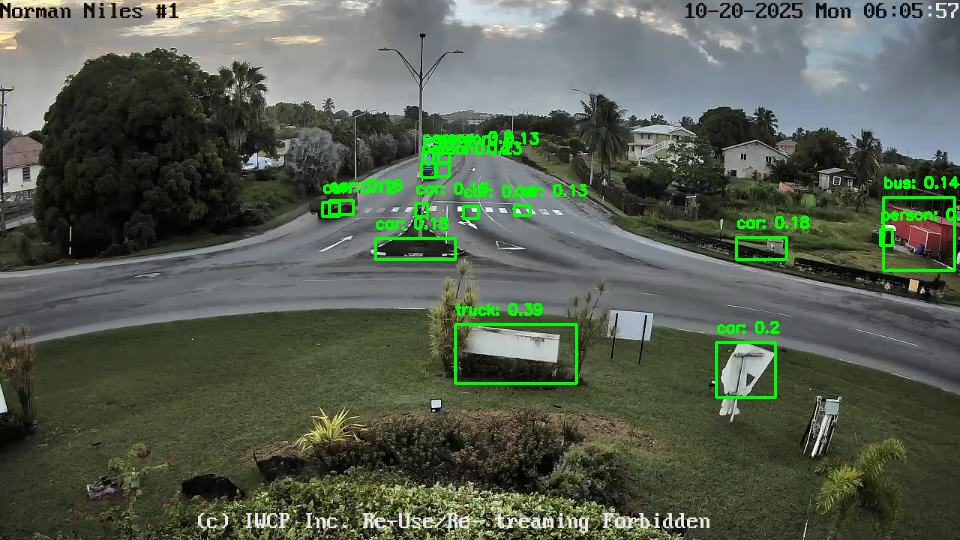

frame index 260
length of detections: 15
Category: truck, Score: 0.3
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.25
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.18
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.18
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.17
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.16
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.16
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.14
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: truck, Score: 0.14
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.14
objects {'c

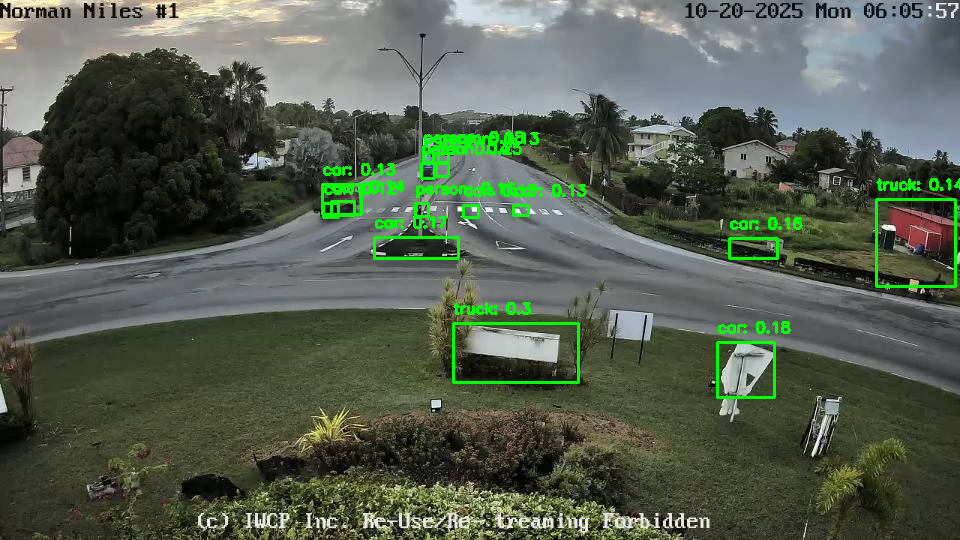

frame index 261
length of detections: 15
Category: truck, Score: 0.3
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.21
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.2
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.18
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.17
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.17
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.16
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: person, Score: 0.14
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.14
objects {'car': 106, 'truck': 10, 'motorcycle': 0, 'person': 0, 'bus': 1}
Category: car, Score: 0.14
objects {'car'

KeyboardInterrupt: 

In [20]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import os
from google.colab.patches import cv2_imshow


model_path = '/absolute/path/to/lite-model_efficientdet_lite0_detection_metadata_1.tflite'

objects = {"car":0,"truck":0,"motorcycle":0,"person":0,"bus":0}

BaseOptions = mp.tasks.BaseOptions
ObjectDetector = mp.tasks.vision.ObjectDetector
ObjectDetectorOptions = mp.tasks.vision.ObjectDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = ObjectDetectorOptions(
    base_options=BaseOptions(model_asset_path='/content/efficientdet.tflite', delegate=BaseOptions.Delegate.GPU),
    max_results=-1,
    score_threshold=0.5,
    running_mode=VisionRunningMode.VIDEO,
    category_allowlist= ["person", "truck", "car", "motorcycle", "bus"],
    )

for video_file_name in os.listdir(video_path):
    with ObjectDetector.create_from_options(options) as detector:
        full_path = os.path.join(video_path, video_file_name)
        cap = cv2.VideoCapture(full_path)
        video_file_fps = cap.get(cv2.CAP_PROP_FPS)
        print(f"Video FPS: {video_file_fps}")
        frame_index = 0
        max_frames_to_process = 100 # Limit frames for demonstration/debugging

        if not cap.isOpened():
            print(f"Error: Could not open video file {full_path}")
            continue

        print(f"Processing video: {video_file_name}")
        while True: # Loop until break
            ret, frame = cap.read()
            if ret:
                pass
            elif not ret:
                break
            # if not ret or frame_index >= max_frames_to_process:
            #     break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

            frame_timestamp_ms = int(1000 * frame_index / video_file_fps) if video_file_fps > 0 else 0

            detection_result = detector.detect_for_video(mp_image, frame_timestamp_ms)
            print("length of detections:", len(detection_result.detections))
            # Draw detections on the frame
            annotated_frame = frame.copy() # Make a copy to draw on
            for detection in detection_result.detections:
                bbox = detection.bounding_box
                start_point = (bbox.origin_x, bbox.origin_y)
                end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)
                cv2.rectangle(annotated_frame, start_point, end_point, (0, 255, 0), 2) # Green rectangle

                category_name = detection.categories[0].category_name if detection.categories else "Unknown"
                score = round(detection.categories[0].score, 2) if detection.categories else 0.0
                if str(category_name) in["person", "truck", "car", "motorcycle", "bus"] and score >= 0.57:
                    objects[str(category_name)] += 1
                print(f"Category: {category_name}, Score: {score}")
                print("objects", objects)
                text = f"{category_name}: {score}"
                cv2.putText(annotated_frame, text, (bbox.origin_x, bbox.origin_y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            cv2_imshow(annotated_frame) # Display the annotated frame
            print("frame index", frame_index)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            frame_index += 1
        print("objects:", objects)
        cap.release() # Release the capture object after processing each video
        cv2.destroyAllWindows() # Close any OpenCV windows (important for local execution environments)


# Task
Explain the video context, including their source and purpose. Detail the structure and content of the `train` DataFrame ('responseId', 'view_label', 'videos') and the `ss` DataFrame ('ID', 'Target'). Illustrate how videos are accessed and downloaded from the "brb-traffic" Google Cloud Storage bucket.

## Explain Video Context

### Subtask:
Provide an explanation of the videos being processed, their source, and their general purpose in the context of the notebook.


The videos currently being processed in this notebook are **traffic videos**. These videos are sourced from the **'brb-traffic' Google Cloud Storage bucket**. The general purpose of processing these videos is to **analyze traffic conditions**. Specifically, we are performing object detection on these videos to identify and count various traffic participants such as cars, trucks, motorcycles, persons, and buses. This analysis can then be used to assess traffic congestion, monitor traffic flow, or extract other relevant traffic-related metrics.

## Describe Training Data

### Subtask:
Detail the structure and content of the 'train' DataFrame, including columns like 'responseId', 'view_label', and 'videos', and how the 'videos' column is transformed to represent paths in the cloud bucket.


## Describe Training Data

### Subtask:
Detail the structure and content of the 'train' DataFrame, including columns like 'responseId', 'view_label', and 'videos', and how the 'videos' column is transformed to represent paths in the cloud bucket.

#### Instructions
1.  **Purpose of the `train` DataFrame**: This DataFrame serves as the primary source of information for the training video segments. Each row represents a specific video segment, containing metadata essential for locating and processing the video.

2.  **Column Explanations**:
    *   `responseId`: This column contains a unique identifier for each video segment entry. It can be used to track individual records.
    *   `view_label`: This column specifies the camera identifier from which the video segment was recorded. It helps in categorizing videos by their source.
    *   `videos`: Initially, this column holds the raw path or name of the video file. After transformation, it represents the path to the video within the Google Cloud Storage bucket, structured as `camera_id/filename.mp4`.

3.  **Transformation of the `videos` Column**: The `extract_camera_path` function is crucial for preparing the `videos` column for cloud storage access. It takes the original video string (e.g., `gs://brb-traffic/normanniles1/normanniles1_2025-10-20-10-04-45.mp4` or just the filename) and processes it to extract the `camera_id` and `filename`. The function then reconstructs the path into the format `camera_id/filename`, which directly corresponds to how the video files are organized within the `brb-traffic` Google Cloud Storage bucket. This transformed path is then used by the `google.cloud.storage` client to download the specific video files.

## Describe Sample Submission Data

### Subtask:
Describe the structure and content of the 'ss' DataFrame used for sample submissions, including its columns 'ID' and 'Target'.


### Description of the `ss` DataFrame

The `ss` DataFrame (SampleSubmission.csv) is used to structure the output of predictions. It contains two key columns:

*   **ID**: This column uniquely identifies each entry for which a prediction is required. It typically contains a string that links back to a specific time segment or video. For example, `time_segment_129_Norman Niles #1_congestion_end_time` likely refers to a specific time segment from a particular camera ('Norman Niles #1') for which a congestion status needs to be predicted.

*   **Target**: This column is where the predicted output should be placed. In the context of traffic congestion prediction, it represents the congestion level (e.g., 'free flowing', 'heavy delay', 'moderate delay', 'light delay'). This column will be populated with the model's predictions after processing the video data.

## Explain Cloud Storage Access

### Subtask:
Illustrate how videos are accessed and downloaded from the specified Google Cloud Storage bucket ('brb-traffic') using the `google.cloud.storage` client.


The process of accessing and downloading videos from Google Cloud Storage involves several key steps:

1.  **Client Initialization**: The `google.cloud.storage.Client` is initialized with the project ID (`"brb-traffic"`). This client object (`client`) acts as the main entry point for interacting with Google Cloud Storage.
    *   *Reference Code Cell*: `uQUhJZzDgr0V`

2.  **Bucket Access**: Once the client is initialized, a specific bucket is accessed using `client.bucket(bucket_name)`. Here, `bucket_name` is set to `'brb-traffic'`, identifying the target storage location.
    *   *Reference Code Cell*: `ffYK00aHvfdY`

3.  **Blob Identification**: Within the selected bucket, individual video files (referred to as 'blobs') are identified. The line `blob = client.bucket(bucket_name).blob(blob_name)` creates a blob object corresponding to a specific video file's path within the bucket.
    *   *Reference Code Cell*: `NZPBpOdDaXWE`

4.  **Filename Extraction**: `os.path.basename(blob_name)` extracts just the filename from the full path of the blob (e.g., `normanniles1_2025-10-20-10-04-45.mp4` from `normanniles1/normanniles1_2025-10-20-10-04-45.mp4`). This ensures the file is saved with its original name locally.
    *   *Reference Code Cell*: `NZPBpOdDaXWE`

5.  **Local Path Definition**: A local path (`local_path`) is constructed using `os.path.join(video_path, file_name)`, which specifies where the downloaded file will be saved in the local Colab environment (e.g., `videos/normanniles1_2025-10-20-10-04-45.mp4`). The `videos` directory is created beforehand.
    *   *Reference Code Cell*: `ffYK00aHvfdY`, `NZPBpOdDaXWE`

6.  **File Download**: Finally, `blob.download_to_filename(local_path)` executes the download, transferring the video file from the Google Cloud Storage bucket to the specified local path in the Colab instance.
    *   *Reference Code Cell*: `NZPBpOdDaXWE`

## Final Task

### Subtask:
Summarize the explanation of the videos and data from the cloud bucket.


## Summary:

### Data Analysis Key Findings

*   **Video Context**: The videos being processed are traffic videos sourced from the 'brb-traffic' Google Cloud Storage bucket. Their purpose is to analyze traffic conditions through object detection, identifying and counting various traffic participants (cars, trucks, motorcycles, persons, buses) to assess congestion and flow.
*   **`train` DataFrame Structure**: This DataFrame serves as the primary source for training video segments.
    *   `responseId`: A unique identifier for each video segment.
    *   `view_label`: Specifies the camera identifier.
    *   `videos`: Initially contains raw video paths/names, then transformed into `camera_id/filename.mp4` to represent the path within the Google Cloud Storage bucket. The `extract_camera_path` function is crucial for this transformation, facilitating access to files in the "brb-traffic" bucket.
*   **`ss` DataFrame Structure**: The `ss` (SampleSubmission.csv) DataFrame is designed to structure prediction outputs.
    *   `ID`: Uniquely identifies each entry requiring a prediction, typically linking to specific time segments or videos (e.g., `time_segment_129_Norman Niles #1_congestion_end_time`).
    *   `Target`: This column is a placeholder for predicted outputs, such as traffic congestion levels ('free flowing', 'heavy delay', etc.).
*   **Google Cloud Storage Access**: Videos are accessed and downloaded from the 'brb-traffic' Google Cloud Storage bucket using the `google.cloud.storage` client through a systematic process involving:
    1.  Initializing the `google.cloud.storage.Client` with the project ID.
    2.  Accessing the specific 'brb-traffic' bucket.
    3.  Identifying individual video files (blobs) by their paths.
    4.  Extracting filenames and defining local paths for saving.
    5.  Downloading the files using `blob.download_to_filename()`.

### Insights or Next Steps

*   The established data structures for `train` and `ss` DataFrames, along with the clearly defined video access methodology, provide a solid foundation for developing and evaluating traffic condition prediction models based on video analysis.
*   The next logical step would involve implementing the object detection and classification algorithms on the downloaded video segments, then populating the `Target` column of the `ss` DataFrame with the derived traffic congestion predictions.
